# Пространственное неравенство

In [ ]:
# import osmnx as ox
import warnings
import sys
import os
from popframe.models.region import Region
import requests
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')


## Подготовка данных

In [ ]:
def preprocess_data(region_id: int, level: int = None) -> gpd.GeoDataFrame:
    """
    Загружает оценки неравенства для всех соцгрупп, вычисляет итоговое
    Пространственное неравенство, подтягивает название и население
    территорий и возвращает итоговый GeoDataFrame.

    Параметры:
        region_id (int): ID региона для запроса оценок.
        level (int, optional): Уровень агрегирования для запроса. По умолчанию None.

    Возвращает:
        GeoDataFrame с колонками:
            - territory_id
            - geometry
            - для каждой соцгруппы: "{name} - Неравенство", "{name} - Неравенство - basic",
              "{name} - Неравенство - additional", "{name} - Неравенство - comfort"
            - "Пространственное неравенство"
            - name (название территории)
            - population (население)
    """
    API_URL = "http://10.32.1.102:5510/provision/{region_id}/get_evaluation"
    URBAN_API = "http://10.32.1.107:5300"
    POP_INDICATOR = 1

    # Список соц‑групп
    social_groups = [
        {"soc_group_id": 1,  "name": "Подростки младшего возраста (14-15)"},
        {"soc_group_id": 2,  "name": "Подростки старшего возраста (16-17)"},
        {"soc_group_id": 3,  "name": "Трудоспособные горожане (18-59)"},
        {"soc_group_id": 4,  "name": "Люди старшего возраста (60-75)"},
        {"soc_group_id": 5,  "name": "Люди преклонного возраста (старше 75)"},
        {"soc_group_id": 6,  "name": "Горожане, ожидающие ребенка"},
        {"soc_group_id": 7,  "name": "Горожане с младенцами"},
        {"soc_group_id": 8,  "name": "Горожане с детьми детсадовского возраста (1-6 лет)"},
        {"soc_group_id": 9,  "name": "Горожане с детьми младшего школьного возраста (7-13 лет)"},
        {"soc_group_id": 10, "name": "Горожане с подростками (14-18 лет)"},
        {"soc_group_id": 11, "name": "Христиане"},
        {"soc_group_id": 12, "name": "Мусульмане"},
        {"soc_group_id": 13, "name": "Иудеи"},
        {"soc_group_id": 14, "name": "Буддисты"},
        {"soc_group_id": 15, "name": "Студенты и учащиеся колледжей"},
        {"soc_group_id": 16, "name": "Горожане с питомцами"},
    ]

    def fetch_gdf(social_group_id: int) -> gpd.GeoDataFrame:
        params = {"region_id": region_id, "level": level, "social_group_id": social_group_id}
        resp = requests.get(API_URL.format(region_id=region_id), params=params)
        resp.raise_for_status()
        data = resp.json()
        gdf = gpd.GeoDataFrame.from_features(data["features"])
        return gdf.set_crs(4326).to_crs(32636)

    def fetch_territories(parent_id: int) -> gpd.GeoDataFrame:
        params = {
            'parent_id': parent_id,
            'get_all_levels': True,
            'cities_only': True,
            'centers_only': True
        }
        resp = requests.get(f"{URBAN_API}/api/v1/all_territories", params=params)
        resp.raise_for_status()
        return gpd.GeoDataFrame.from_features(resp.json()['features']).set_crs(4326)

    def get_population(terr_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        resp = requests.get(f"{URBAN_API}/api/v1/indicator/{POP_INDICATOR}/values", verify=False)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
        df['territory_id'] = df['territory'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
        pop = df.groupby('territory_id')['value'].last().reset_index().rename(columns={'value': 'population'})
        terr_gdf = terr_gdf.rename_axis('idx').reset_index()
        terr_gdf = terr_gdf.merge(pop, on='territory_id', how='left')
        terr_gdf['population'] = terr_gdf['population'].fillna(0)
        return terr_gdf.set_index('idx')

    # 1) Базовая таблица
    first = social_groups[0]
    gdf_base = fetch_gdf(first["soc_group_id"])
    gdf_final = gdf_base[['territory_id', 'geometry']].copy()
    metrics = ["Обеспеченность", "basic", "additional", "comfort"]

    # 2) Делаем merge для всех соц‑групп
    for grp in tqdm(social_groups, desc="Обработка соц-групп"):
        gdf_i = fetch_gdf(grp["soc_group_id"])
        df_i = gdf_i[['territory_id'] + metrics].rename(columns={
            "Обеспеченность":            f"{grp['name']} - Неравенство",
            "basic":                     f"{grp['name']} - Неравенство - basic",
            "additional":                f"{grp['name']} - Неравенство - additional",
            "comfort":                   f"{grp['name']} - Неравенство - comfort",
        })
        gdf_final = gdf_final.merge(df_i, on='territory_id', how='left')

    # 3) Инвертируем (1 - value) для всех Неравенство-столбцов
    ine_cols = [c for c in gdf_final.columns if "Неравенство" in c]
    gdf_final[ine_cols] = 1 - gdf_final[ine_cols]

    # 4) Итоговое Пространственное неравенство
    gdf_final["Пространственное неравенство"] = gdf_final[ine_cols].mean(axis=1).round(2)

    # 5) Подтягиваем name и population
    terrs = fetch_territories(parent_id=region_id)
    terrs = get_population(terrs)
    attrs = terrs[['territory_id', 'name', 'population']]
    gdf_final = gdf_final.merge(attrs, on='territory_id', how='left')

    return gdf_final


In [4]:
gdf_final = preprocess_data(region_id=1, level=None)
gdf_final.head()


,territory_id,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population
0,207,POINT (542576.859 6580696.856),0.75,0.83,0.25,1.0,0.76,0.83,0.25,1.0,...,0.83,0.25,1.0,0.76,0.83,0.25,1.0,0.71,деревня Болото,10.0
1,208,POINT (544527.863 6593642.176),0.56,0.58,0.12,1.0,0.59,0.58,0.12,1.0,...,0.58,0.12,1.0,0.58,0.58,0.12,1.0,0.57,деревня Большой Остров,68.0
2,209,POINT (544980.557 6593207.96),0.41,0.33,0.12,1.0,0.44,0.33,0.12,1.0,...,0.33,0.12,1.0,0.42,0.33,0.12,1.0,0.47,деревня Бор,1734.0
3,210,POINT (543991.333 6589719.929),0.69,0.75,0.25,1.0,0.71,0.75,0.25,1.0,...,0.75,0.25,1.0,0.70,0.75,0.25,1.0,0.67,деревня Бороватое,10.0
4,211,POINT (538619.331 6577374.018),0.78,0.83,0.38,1.0,0.79,0.83,0.38,1.0,...,0.83,0.38,1.0,0.79,0.83,0.38,1.0,0.74,деревня Бочево,10.0


In [ ]:
# gdf_final.to_file('spatial_inequality_LO_towns.geojson')

## Тестовый пример

In [ ]:
gdf_cities  = gpd.read_file('data/spatial_inequality_LO_towns.geojson')
gdf_cities.head(4)

In [ ]:
gdf_agglomerations = gpd.read_file('data/settlement_boundaries.geojson')
# gdf_agglomerations = gpd.read_file('data/final_agglomerations.geojson')
gdf_agglomerations.head(5)

In [91]:
from popframe.method.spatial_inequality import SpatialInequalityCalculator

region_model = Region.from_pickle('data/1.pickle')
calculator = SpatialInequalityCalculator(region=region_model)

## Пространственное неравенство для территорий (полигонов) по группам населения

In [92]:
# 3) Переносим метрики неравенства из городов на полигоны
gdf_polys_with_metrics, stats = calculator.transfer_inequality_metrics_to_polygons(
    gdf_cities,
    gdf_agglomerations,
    inequality_keyword="Неравенство"
)
stats

{'mean_within': {'Подростки младшего возраста (14-15) - Неравенство': 0.6338924731182796,
  'Подростки младшего возраста (14-15) - Неравенство - basic': 0.6906967741935484,
  'Подростки младшего возраста (14-15) - Неравенство - additional': 0.3650924731182796,
  'Подростки младшего возраста (14-15) - Неравенство - comfort': 0.8671225806451612,
  'Подростки старшего возраста (16-17) - Неравенство': 0.6455698924731182,
  'Подростки старшего возраста (16-17) - Неравенство - basic': 0.6906967741935484,
  'Подростки старшего возраста (16-17) - Неравенство - additional': 0.3650924731182796,
  'Подростки старшего возраста (16-17) - Неравенство - comfort': 0.8377763440860215,
  'Трудоспособные горожане (18-59) - Неравенство': 0.6255053763440861,
  'Трудоспособные горожане (18-59) - Неравенство - basic': 0.639247311827957,
  'Трудоспособные горожане (18-59) - Неравенство - additional': 0.4478236559139785,
  'Трудоспособные горожане (18-59) - Неравенство - comfort': 0.7209247311827958,
  'Люди с

In [93]:
gdf_polys_with_metrics.head(3)

,anchor_name,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Буддисты - Неравенство - comfort,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство
poly_index,,,,,,,,,,,,,,,,,,,,,
0,город Приозерск,"POLYGON ((327427.183 6730670.252, 327136.101 6...",0.532121,0.583939,0.296212,0.913333,0.559394,0.583939,0.296212,0.926515,...,0.913333,0.545758,0.583939,0.296212,0.926515,0.545758,0.583939,0.296212,0.913333,0.577424
1,город Луга,"POLYGON ((287016.41 6543947.996, 287016.796 65...",0.647885,0.731630,0.351894,0.804317,0.669031,0.731630,0.351894,0.833700,...,0.804317,0.660617,0.731630,0.351894,0.833700,0.660573,0.731630,0.351894,0.804317,0.631057
2,город Сланцы,"POLYGON ((197917.925 6549729.864, 197918.01 65...",0.797669,0.800902,0.706391,0.827068,0.799398,0.800902,0.706391,0.853158,...,0.827068,0.804135,0.800902,0.706391,0.853158,0.804135,0.800902,0.706391,0.827068,0.778872


In [94]:
region_boundary = region_model.region

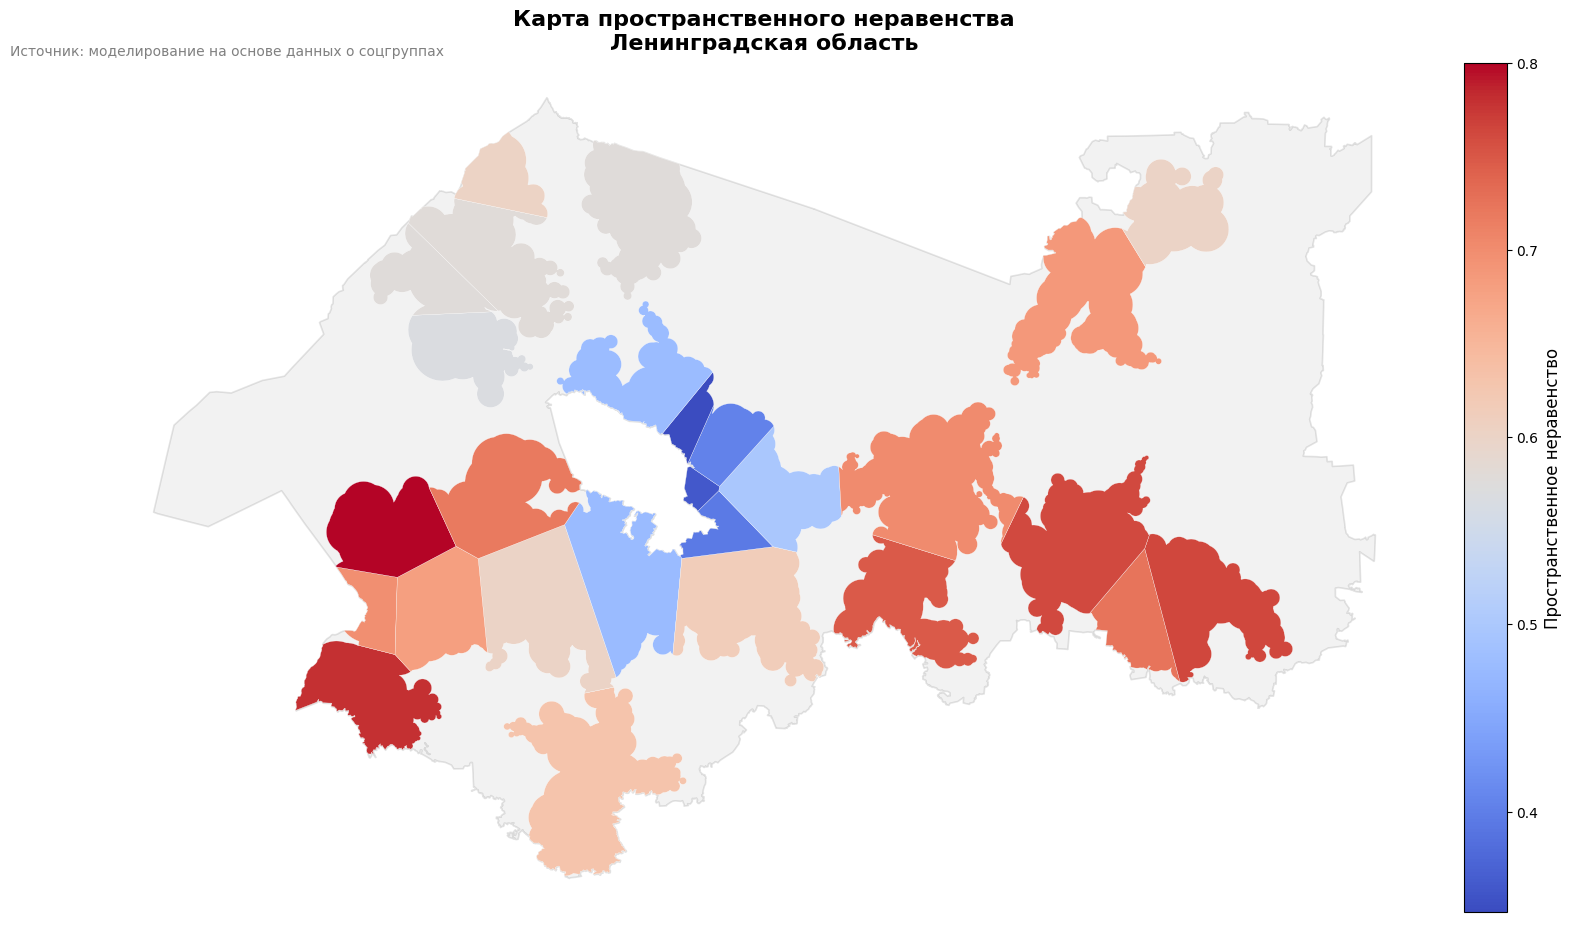

In [95]:
import matplotlib.pyplot as plt
import contextily as ctx

# создаём фигуру и ось
fig, ax = plt.subplots(figsize=(15, 10), dpi=100)

# рисуем границу региона
region_boundary.plot(
    ax=ax,
    facecolor="gray",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.1,
    label="Граница региона"
)

# рисуем полигоны с показателем "Пространственное неравенство"
# используем diverging cmap и центрируем цветовую шкалу в среднем значении
vmin = gdf_polys_with_metrics['Пространственное неравенство'].min()
vmax = gdf_polys_with_metrics['Пространственное неравенство'].max()
vcenter = gdf_polys_with_metrics['Пространственное неравенство'].mean()

gdf_polys_with_metrics.plot(
    column='Пространственное неравенство',
    cmap='coolwarm',
    linewidth=0.2,
    edgecolor='white',
    ax=ax,
    legend=False  # legend сделаем вручную
)

# добавляем градиентный colorbar
sm = plt.cm.ScalarMappable(
    cmap='coolwarm',
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])  # пустой, чтобы цветовая шкала работала
cbar = fig.colorbar(
    sm, ax=ax, fraction=0.03, pad=0.02
)
cbar.set_label("Пространственное неравенство", fontsize=12)
cbar.ax.tick_params(labelsize=10)



# убираем оси
ax.set_axis_off()

# заголовок и пояснение
ax.set_title(
    "Карта пространственного неравенства\nЛенинградская область",
    fontdict={'fontsize': 16, 'fontweight': 'bold'}
)
fig.suptitle(
    "Источник: моделирование на основе данных о соцгруппах", 
    x=0.1, y=0.92, 
    fontsize=10, 
    color='gray'
)

# легенда (если нужно)
ax.legend(loc='lower left', fontsize=10, frameon=False)

plt.tight_layout()
plt.show()



## Лучшие территории по наименьшему неравенству

In [96]:
best_youth = calculator.get_best_territory(
    gdf_polys_with_metrics,
    group_name="Подростки младшего возраста (14-15)",
    top_n= 3 # опционально, сколько лучших территорий показать (по умолчанию 5)
)
best_youth

,anchor_name,geometry,Пространственное неравенство,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort
poly_index,,,,,,,
24,город Мурино,"POLYGON ((351375.352 6664593.09, 351374.724 66...",0.346316,0.301579,0.324211,0.140526,0.635789
20,город Кудрово,"POLYGON ((359656.173 6637951.473, 359656.203 6...",0.359231,0.363462,0.343077,0.000000,0.793846
18,город Отрадное,"POLYGON ((358256.176 6613983.925, 358256.291 6...",0.395714,0.401071,0.368571,0.081429,0.768571


In [97]:
# 5) Находим территорию с минимальным общим неравенством
best_overall = calculator.get_best_territory(
    gdf_cities)
best_overall

,territory_id,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,Трудоспособные горожане (18-59) - Неравенство,...,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population,geometry
1060,1267,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,город Сосновый Бор,63462.0,POINT (283470.037 6644117.652)
1585,1792,0.22,0.25,0.00,0.20,0.24,0.25,0.00,0.17,0.23,...,0.00,0.17,0.24,0.25,0.00,0.20,0.16,деревня Шереметьевка,44.0,POINT (389284.621 6648362.546)
2621,2828,0.19,0.17,0.12,0.20,0.24,0.17,0.12,0.33,0.23,...,0.12,0.33,0.21,0.17,0.12,0.20,0.17,деревня Фишева Гора,5.0,POINT (530645.861 6611990.519)
1651,1858,0.16,0.23,0.12,0.25,0.21,0.23,0.12,0.38,0.18,...,0.12,0.38,0.18,0.23,0.12,0.25,0.19,деревня Энколово,412.0,POINT (356965.492 6666121.124)
1654,1861,0.16,0.25,0.12,0.20,0.21,0.25,0.12,0.33,0.18,...,0.12,0.33,0.18,0.25,0.12,0.20,0.19,деревня Корабсельки,200.0,POINT (355472.818 6665585.5)


## Соц. группа с наименьшим неравенством

In [148]:

cities_with_best_group = calculator.get_best_group_for_territory(
    gdf_cities
)
cities_with_best_group.head(3)

,territory_id,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,Трудоспособные горожане (18-59) - Неравенство,...,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population,geometry,Наименьшее неравенство для соц‑группы
0,207,0.75,0.83,0.25,1.0,0.76,0.83,0.25,1.0,0.74,...,1.0,0.76,0.83,0.25,1.0,0.71,деревня Болото,10.0,POINT (542576.859 6580696.856),Люди преклонного возраста (старше 75)
1,208,0.56,0.58,0.12,1.0,0.59,0.58,0.12,1.0,0.59,...,1.0,0.58,0.58,0.12,1.0,0.57,деревня Большой Остров,68.0,POINT (544527.863 6593642.176),Подростки младшего возраста (14-15)
2,209,0.41,0.33,0.12,1.0,0.44,0.33,0.12,1.0,0.46,...,1.0,0.42,0.33,0.12,1.0,0.47,деревня Бор,1734.0,POINT (544980.557 6593207.96),Подростки младшего возраста (14-15)


In [109]:

gdf_with_best_group = calculator.get_best_group_for_territory(
    gdf_polys_with_metrics
)
gdf_with_best_group.head(3)

,anchor_name,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,Наименьшее неравенство для соц‑группы
poly_index,,,,,,,,,,,,,,,,,,,,,
0,город Приозерск,"POLYGON ((327427.183 6730670.252, 327136.101 6...",0.532121,0.583939,0.296212,0.913333,0.559394,0.583939,0.296212,0.926515,...,0.545758,0.583939,0.296212,0.926515,0.545758,0.583939,0.296212,0.913333,0.577424,Люди преклонного возраста (старше 75)
1,город Луга,"POLYGON ((287016.41 6543947.996, 287016.796 65...",0.647885,0.731630,0.351894,0.804317,0.669031,0.731630,0.351894,0.833700,...,0.660617,0.731630,0.351894,0.833700,0.660573,0.731630,0.351894,0.804317,0.631057,Люди преклонного возраста (старше 75)
2,город Сланцы,"POLYGON ((197917.925 6549729.864, 197918.01 65...",0.797669,0.800902,0.706391,0.827068,0.799398,0.800902,0.706391,0.853158,...,0.804135,0.800902,0.706391,0.853158,0.804135,0.800902,0.706391,0.827068,0.778872,Люди старшего возраста (60-75)


## Визуализация

In [116]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_spatial_metric(
    region_boundary,
    gdf_polys,
    gdf_cities,
    attr: str,
    city_thresh: float = None,
    figsize=(15, 10),
    dpi=120,
    cmap='RdYlBu_r'
):
    """
    Рисует карту: полигоны и (опционально отфильтрованные) города, 
    раскрашенные по атрибуту attr.

    Параметры
    ----------
    region_boundary : GeoDataFrame
        Полигон(ы) границы региона.
    gdf_polys : GeoDataFrame
        Полигоны с метриками (должен содержать колонку attr).
    gdf_cities : GeoDataFrame
        Точки‑города (должны содержать колонку attr).
    attr : str
        Название колонки для цветового кода.
    city_thresh : float, optional
        Если задан, то показываем только города с gdf_cities[attr] ≤ city_thresh.
    figsize : tuple, default (15, 10)
        Размер фигуры.
    dpi : int, default 120
        Разрешение в dpi.
    cmap : str, default 'RdYlBu_r'
        Имя matplotlib‑палитры.
    """
    # Переводим всё в WebMercator
    region_web = region_boundary.to_crs(epsg=3857)
    polys_web  = gdf_polys.to_crs(epsg=3857)
    cities_web = gdf_cities.to_crs(epsg=3857)

    # При необходимости фильтруем города
    if city_thresh is not None:
        cities_web = cities_web[cities_web[attr] <= city_thresh]

    # Границы шкалы
    vmin    = polys_web[attr].min()
    vmax    = polys_web[attr].max()
    vcenter = polys_web[attr].mean()
    norm    = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # Рисуем
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # 1) Полигоны
    polys_web.plot(
        column=attr,
        cmap=cmap,
        norm=norm,
        linewidth=0.1,
        edgecolor='gray',
        alpha=1,
        ax=ax
    )

    # 2) Города
    cities_web.plot(
        column=attr,
        cmap=cmap,
        norm=norm,
        markersize=20,
        alpha=0.7,
        edgecolor='none',
        ax=ax
    )

    # 3) Лёгкая рамка региона
    region_web.plot(
        ax=ax,
        facecolor="gray",
        edgecolor="lightgray",
        linewidth=1.2,
        alpha=0.2
    )

    # 4) Общий colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(attr, fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # 5) Оформление заголовков
    ax.set_title(
        f"{attr}\nв Ленинградской области",
        fontdict={'fontsize':16, 'fontweight':'bold'}
    )
    if city_thresh is not None:
        fig.suptitle( "Источник: моделирование на основе данных о соцгруппах. \n"
            f" (Социальная групапа  - {attr} ≤ {city_thresh})",
            x=0.1, y=0.07,
            fontsize=10,
            color='gray'
        )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    return fig, ax


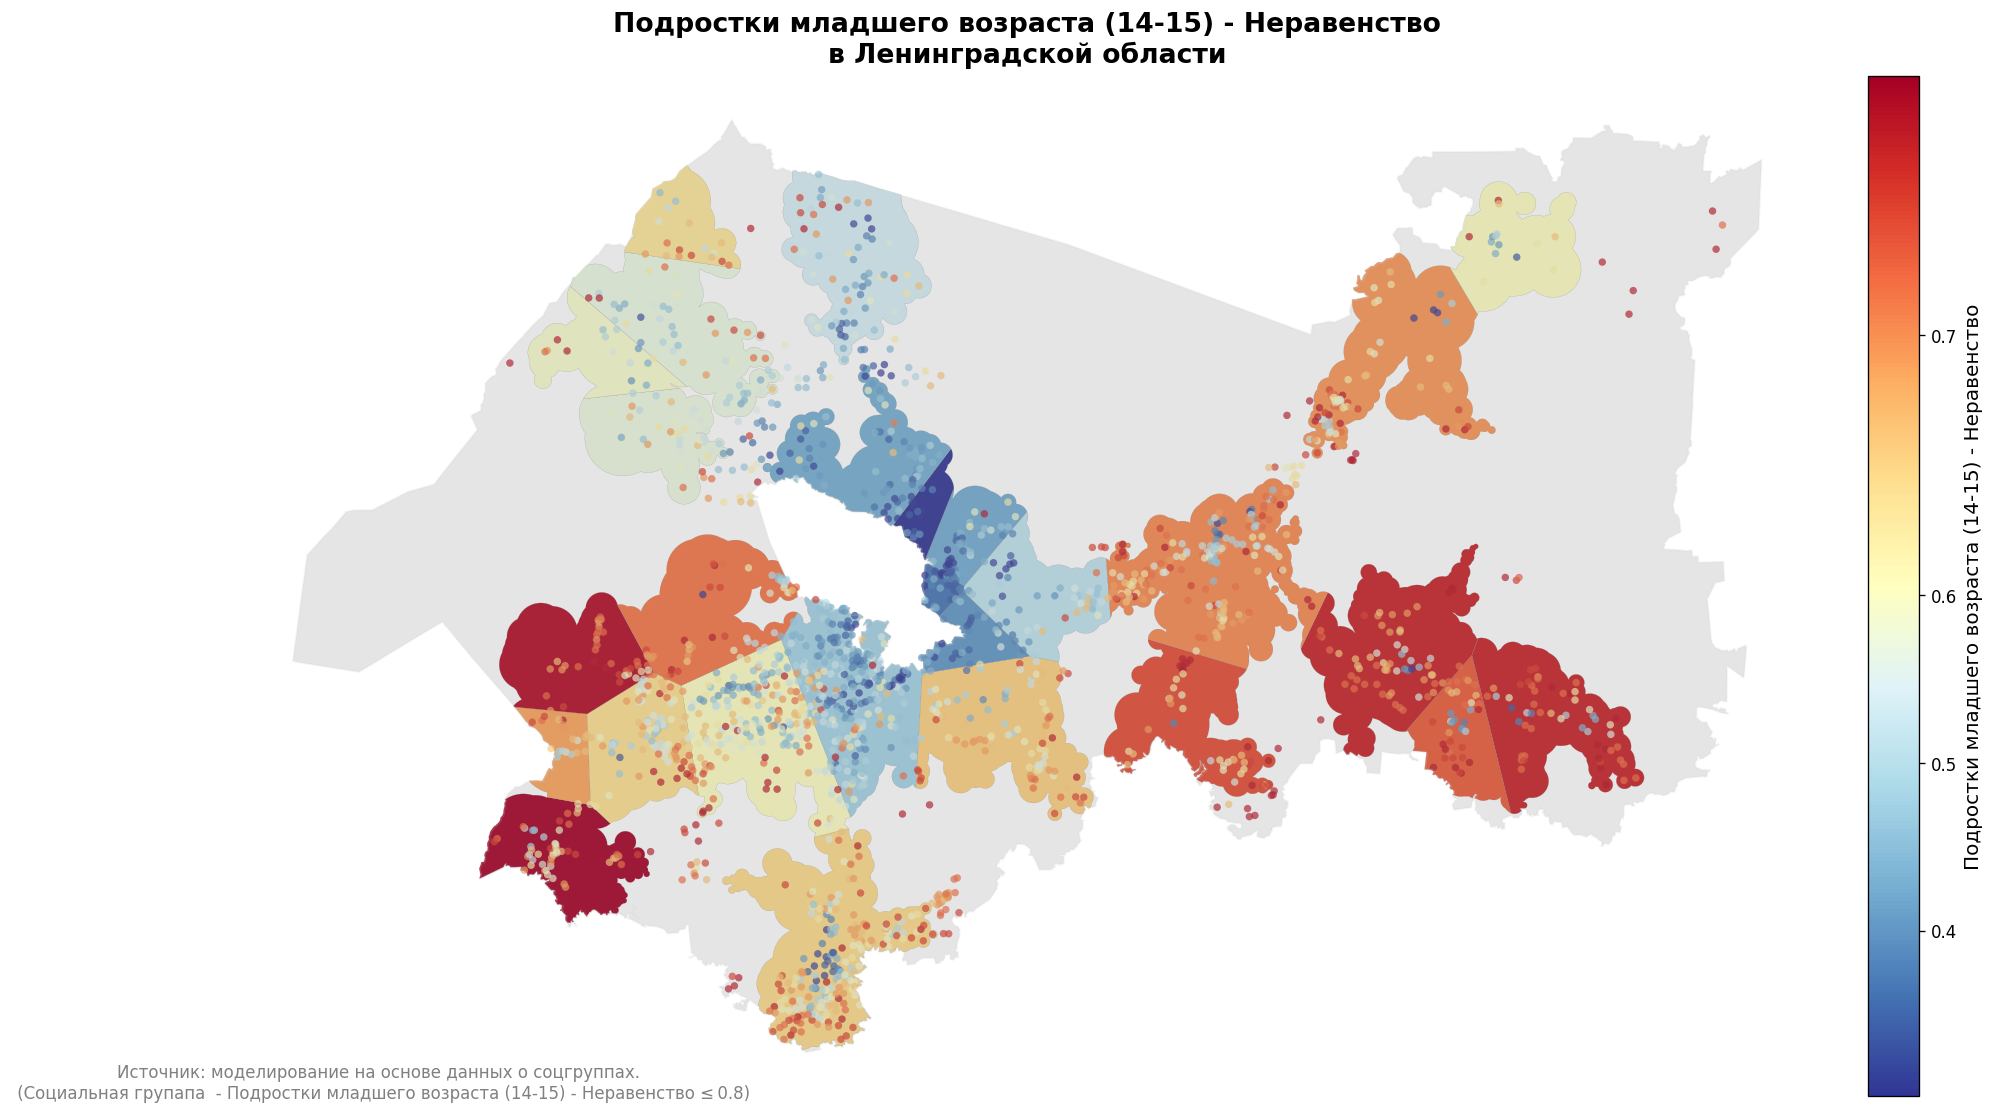

(<Figure size 1800x1200 with 2 Axes>,
 <Axes: title={'center': 'Подростки младшего возраста (14-15) - Неравенство\nв Ленинградской области'}>)

In [101]:
# визуализируем 'Пространственное неравенство', показывая города с ≤ 0.8
plot_spatial_metric(
    region_boundary=region_boundary,
    gdf_polys=gdf_polys_with_metrics,
    gdf_cities=gdf_cities,
    attr='Подростки младшего возраста (14-15) - Неравенство',
    city_thresh=0.8
)


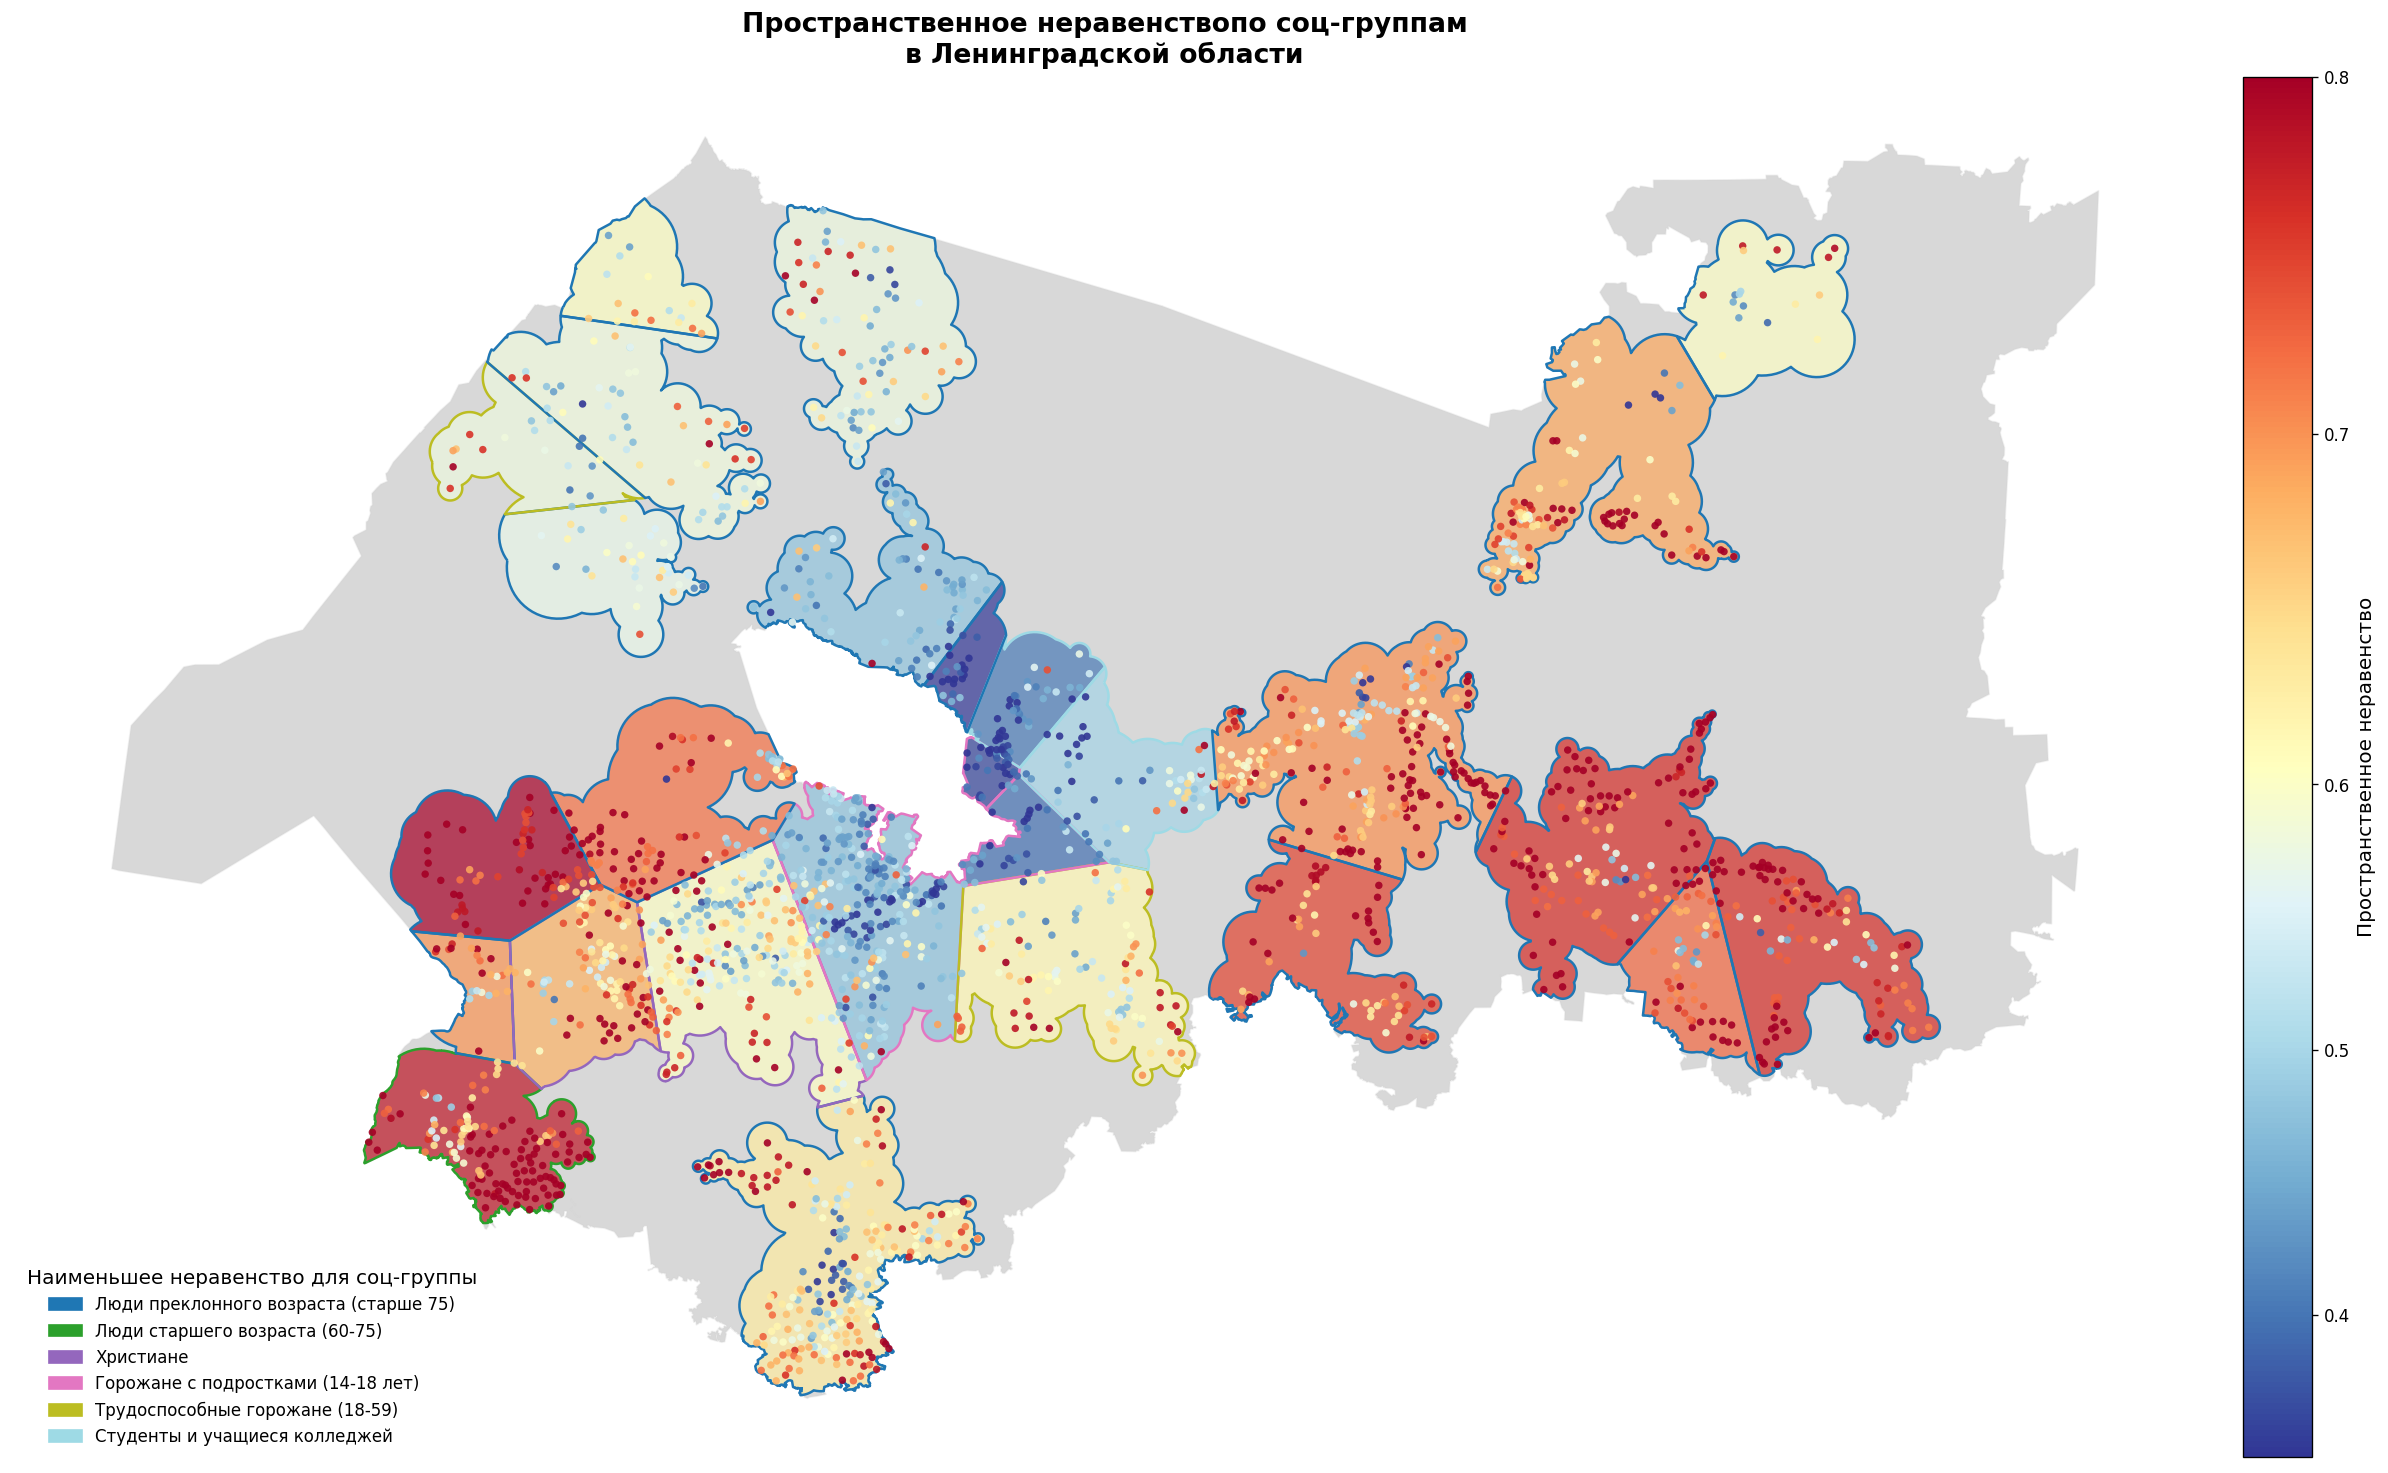

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from shapely.ops import unary_union

# --- Предполагаем, что region_web, polys_web и cities_web уже в EPSG:3857 ---
# 1) Переводим всё в Web Mercator
region_web = region_boundary.to_crs(epsg=3857)
polys_web  = gdf_with_best_group.to_crs(epsg=3857)
cities_web = gdf_cities.to_crs(epsg=3857)
# 1) Только города внутри полигонов
union_poly      = unary_union(polys_web.geometry)
cities_in_polys = cities_web[cities_web.geometry.within(union_poly)]

# 2) Нормировка
numeric_attr = 'Пространственное неравенство'
vmin    = polys_web[numeric_attr].min()
vmax    = polys_web[numeric_attr].max()
vcenter = polys_web[numeric_attr].mean()
norm    = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# 3) Цвета групп без NaN
group_attr = 'Наименьшее неравенство для соц‑группы'
groups = polys_web[group_attr].dropna().astype(str)
unique_groups = list(dict.fromkeys(groups))
cmap_groups   = plt.cm.get_cmap('tab20', len(unique_groups))
group_colors  = {grp: cmap_groups(i) for i, grp in enumerate(unique_groups)}
polys_web['__group_color'] = polys_web[group_attr].map(lambda x: group_colors.get(str(x)))
# 4) Рисуем
fig, ax = plt.subplots(figsize=(20, 15), dpi=120)

# фон
region_web.plot(facecolor='gray', edgecolor='lightgray', alpha=0.3, ax=ax, zorder=0)

# заливка с белой обводкой
polys_web.plot(
    column=numeric_attr,
    cmap='RdYlBu_r',
    norm=norm,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    ax=ax,
    zorder=1
)

# цветные границы групп
mask = polys_web[group_attr].notna()
polys_web[mask].boundary.plot(
    color=polys_web.loc[mask, '__group_color'],
    linewidth=1.5,
    ax=ax,
    zorder=2
)

# города
cities_in_polys.plot(
    column=numeric_attr,
    cmap='RdYlBu_r',
    norm=norm,
    markersize=20,
    alpha=0.9,
    edgecolor='none',
    linewidth=0.1,
    ax=ax,
    zorder=3
)

# легенда групп слева-снизу (без NaN)
legend_patches = [
    mpatches.Patch(color=group_colors[grp], label=grp)
    for grp in unique_groups
]
leg = ax.legend(
    handles=legend_patches,
    title=group_attr,
    loc='lower left',
    fontsize=10,
    title_fontsize=12,
    frameon=False
)
# (опционально) если вам нужно поднять легенду поверх всех:
leg.set_zorder(5)

# colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(numeric_attr, fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title(
    f"{numeric_attr}по соц‑группам\nв Ленинградской области",
    fontdict={'fontsize':16, 'fontweight':'bold'}
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


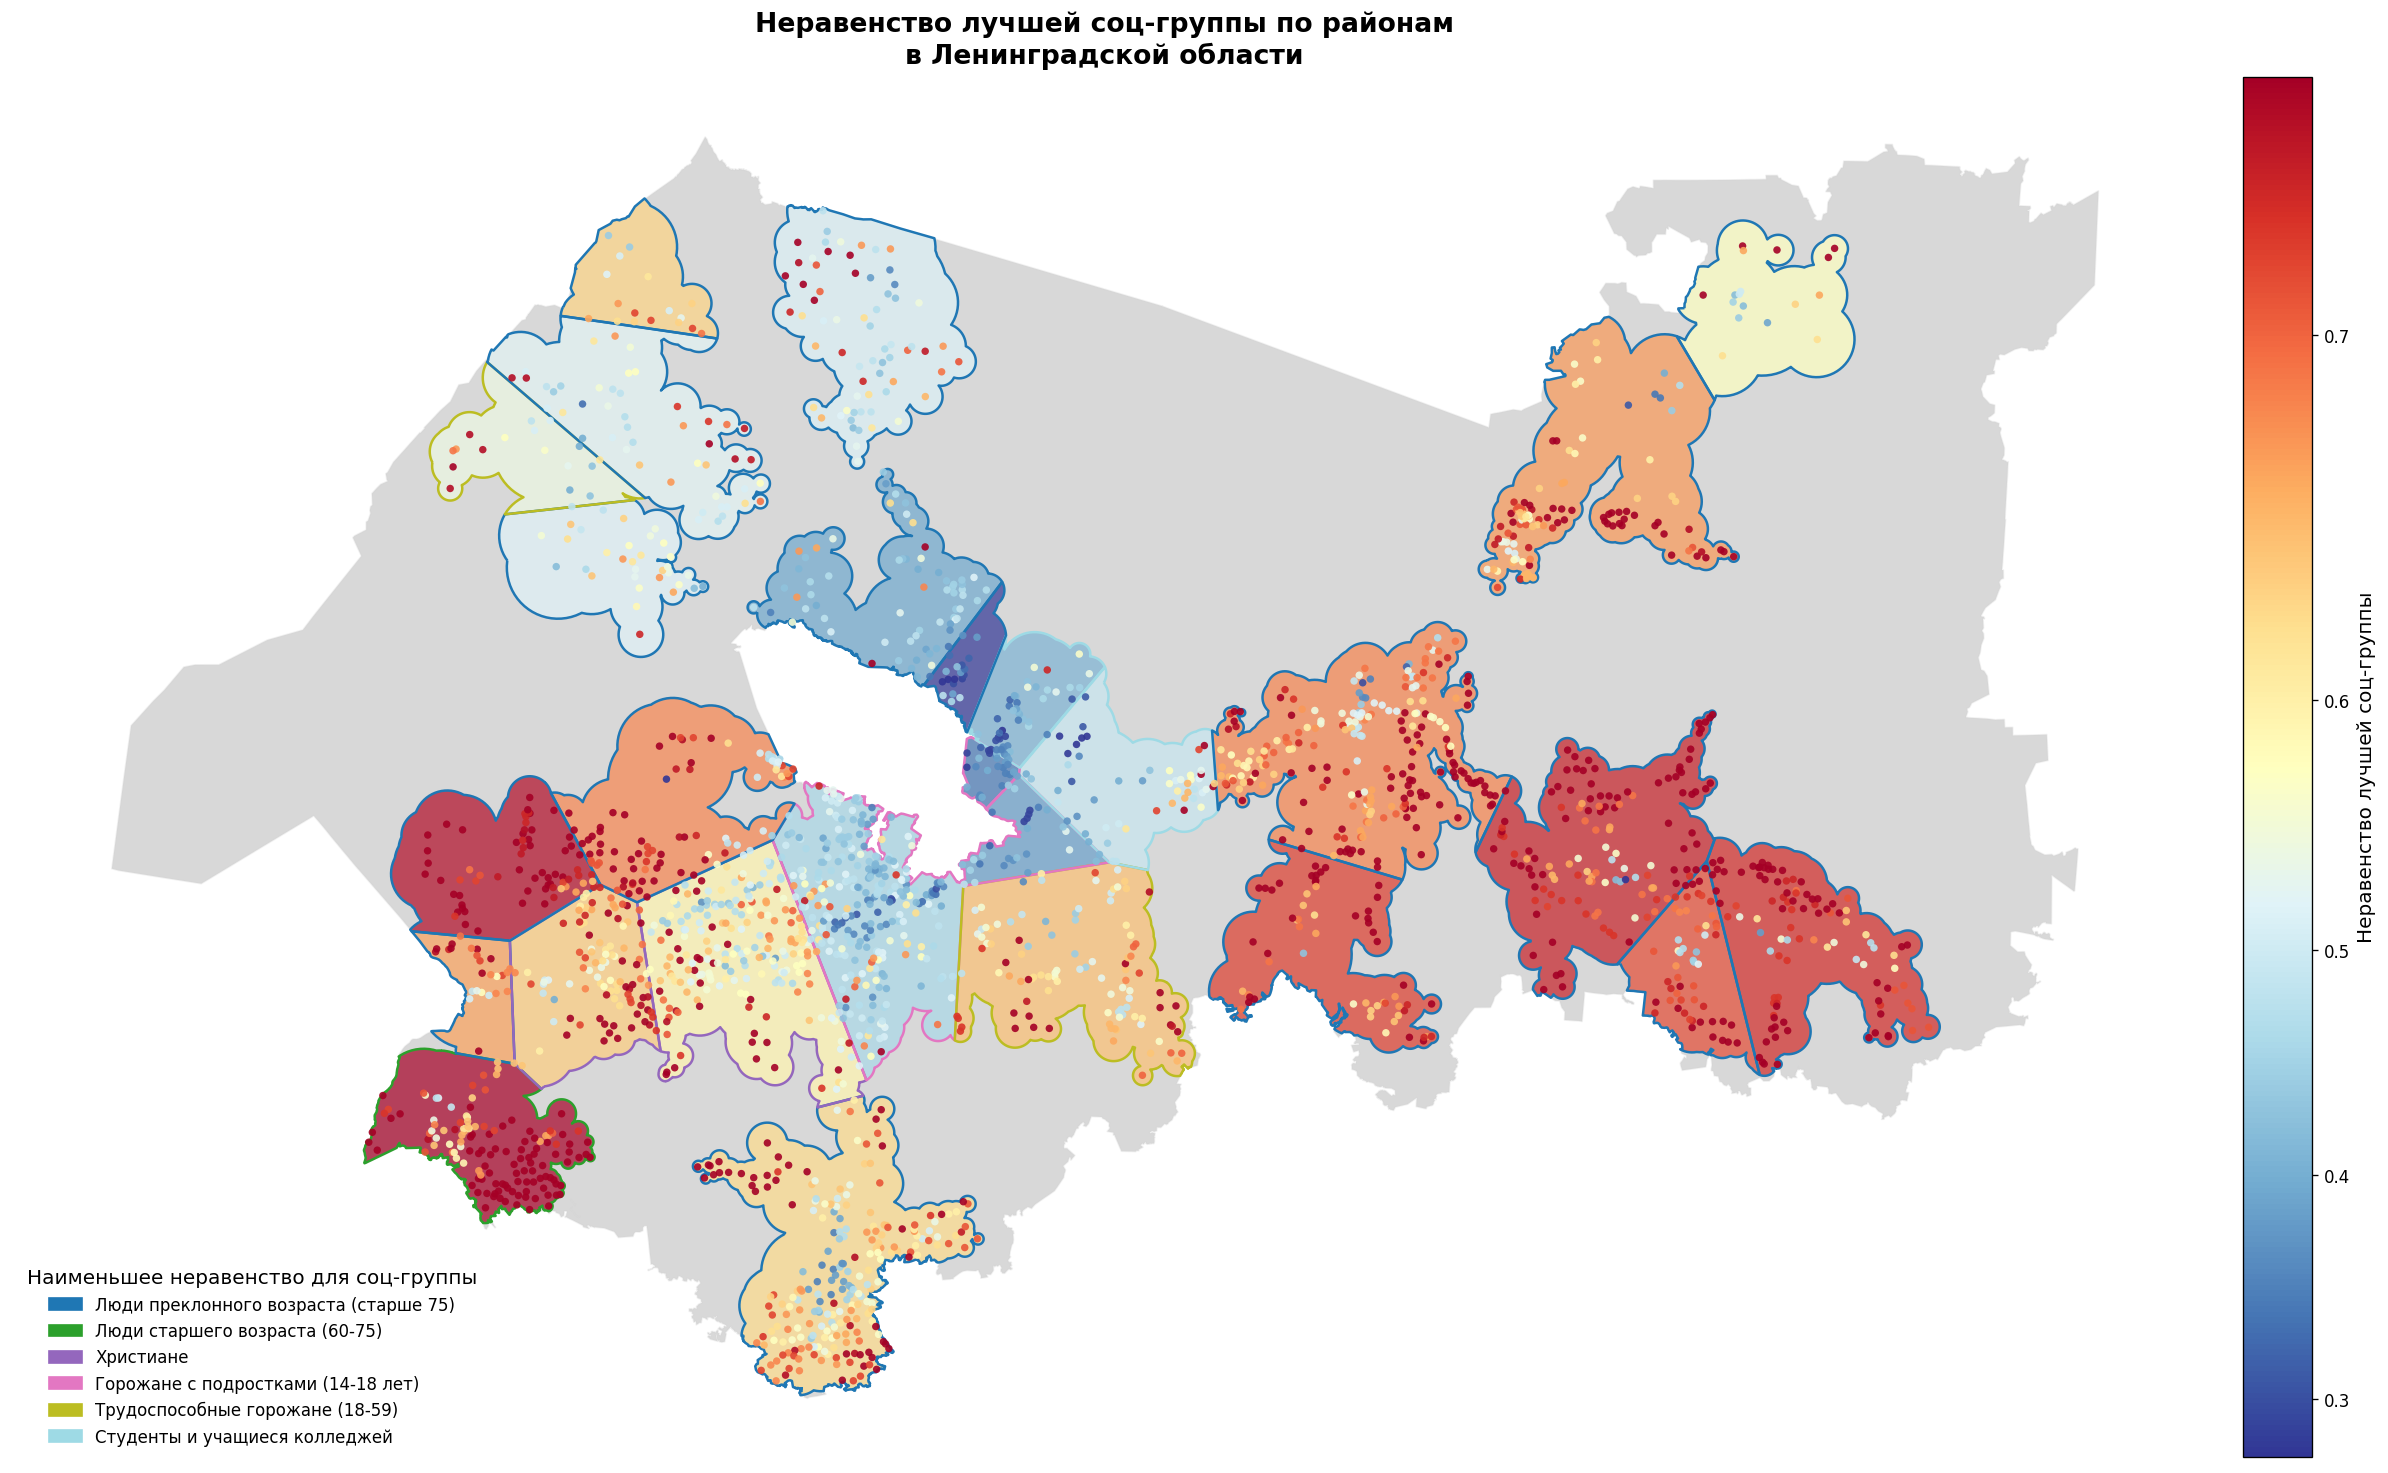

In [136]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from shapely.ops import unary_union
import numpy as np

# --- 1) В CRS WebMercator ---
region_web = region_boundary.to_crs(epsg=3857)
polys_web  = gdf_with_best_group.to_crs(epsg=3857)
cities_web = gdf_cities.to_crs(epsg=3857)

# --- 2) Оставляем города внутри опорных полигонов ---
union_poly      = unary_union(polys_web.geometry)
cities_in_polys = cities_web[cities_web.geometry.within(union_poly)]

# --- 3) Вычисляем для каждого полигона значение неравенства «лучшей» группы ---
# наз­вание колонки с именем лучшей группы
group_attr = 'Наименьшее неравенство для соц‑группы'

def extract_best_ineq(row):
    # у нас в gdf есть колонки вида "<название группы> - Неравенство"
    best_group = row[group_attr]
    if pd.isna(best_group):
        return np.nan
    col_name = f"{best_group} - Неравенство"
    return row.get(col_name, np.nan)

polys_web['best_ineq'] = polys_web.apply(extract_best_ineq, axis=1)

# --- 4) Нормировка по новой величине ---
numeric_attr = 'best_ineq'
vmin    = polys_web[numeric_attr].min()
vmax    = polys_web[numeric_attr].max()
vcenter = polys_web[numeric_attr].mean()
norm    = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# --- 5) Готовим цвета для обводки по группам (как раньше) ---
groups = polys_web[group_attr].dropna().astype(str)
unique_groups = list(dict.fromkeys(groups))
cmap_groups  = plt.cm.get_cmap('tab20', len(unique_groups))
group_colors = {grp: cmap_groups(i) for i, grp in enumerate(unique_groups)}
polys_web['__group_color'] = polys_web[group_attr].map(lambda x: group_colors.get(str(x), None))

# --- 6) Рисуем карту ---
fig, ax = plt.subplots(figsize=(20, 15), dpi=120)

# фон
region_web.plot(facecolor='gray', edgecolor='lightgray', alpha=0.3, ax=ax, zorder=0)

# заливка полигонов по best_ineq, с белой прослойкой
polys_web.plot(
    column=numeric_attr,
    cmap='RdYlBu_r',
    norm=norm,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    ax=ax,
    zorder=1
)

# обводка цветом группы
mask = polys_web[group_attr].notna()
polys_web[mask].boundary.plot(
    color=polys_web.loc[mask, '__group_color'],
    linewidth=1.5,
    ax=ax,
    zorder=2
)

# города (если нужно, можно тоже по best_ineq или по-global)
cities_in_polys.plot(
    column='Пространственное неравенство',  # или numeric_attr
    cmap='RdYlBu_r',
    norm=norm,
    markersize=20,
    alpha=0.9,
    edgecolor='none',
    linewidth=0.1,
    ax=ax,
    zorder=3
)

# легенда «группа» слева‑снизу без NaN
legend_patches = [
    mpatches.Patch(color=group_colors[grp], label=grp)
    for grp in unique_groups
]
ax.legend(
    handles=legend_patches,
    title=group_attr,
    loc='lower left',
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

# общий colorbar для best_ineq
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Неравенство лучшей соц‑группы', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title(
    "Неравенство лучшей соц‑группы по районам\nв Ленинградской области",
    fontdict={'fontsize':16, 'fontweight':'bold'}
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [152]:
import folium
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union
import matplotlib as mpl
import matplotlib.colors as mcolors

# --- 1) Переводим GeoDataFrame в WGS84 ---
polys = gdf_with_best_group.to_crs(epsg=4326)
cities = gdf_cities.to_crs(epsg=4326)

# --- 2) Вычисляем для каждого полигона значение неравенства лучшей соц‑группы ---
def extract_best_ineq(row):
    best = row.get('Наименьшее неравенство для соц‑группы')
    if pd.isna(best):
        return np.nan
    return row.get(f"{best} - Неравенство", np.nan)

polys['best_ineq'] = polys.apply(extract_best_ineq, axis=1)

# --- 3) Задаём нормировки и палитры из Matplotlib ---
# для полигонов по best_ineq
vmin_p = polys['best_ineq'].min()
vmax_p = polys['best_ineq'].max()
norm_p = mpl.colors.TwoSlopeNorm(vmin=vmin_p, vcenter=(vmin_p+vmax_p)/2, vmax=vmax_p)
cmap_p = mpl.cm.get_cmap('RdYlBu_r')

# для городов по их пространственному неравенству
vmin_c = cities['Пространственное неравенство'].min()
vmax_c = cities['Пространственное неравенство'].max()
norm_c = mpl.colors.TwoSlopeNorm(vmin=vmin_c, vcenter=(vmin_c+vmax_c)/2, vmax=vmax_c)
cmap_c = mpl.cm.get_cmap('RdYlBu_r')

# --- 4) Готовим цвета для обводки полигонов по лучшей группе ---
group_attr = 'Наименьшее неравенство для соц‑группы'
groups = polys[group_attr].dropna().astype(str)
unique_groups = list(dict.fromkeys(groups))
cmap_groups = mpl.cm.get_cmap('tab20', len(unique_groups))
group_colors = {grp: mcolors.to_hex(cmap_groups(i)) for i, grp in enumerate(unique_groups)}

def fmt(val):
    try:
        return f"{float(val):.3f}"
    except:
        return "-"

def popup_poly(row):
    # теперь заголовок «Опорный населённый пункт: <название>»
    name = row.get('anchor_name', '—')
    lines = [f"<b>Опорный населенный пункт: {name}</b>"]
    
    si = row.get('Пространственное неравенство')
    if pd.notna(si):
        lines.append(f"Пространственное неравенство: <b>{fmt(si)}</b>")
    
    best = row.get(group_attr)
    if pd.notna(best):
        lines.append(f"Наиболее обеспеченная соц-группа: <b>{best}</b>")
        for suffix, label in [
            ('- basic', 'Базовая инфраструктура'),
            ('- additional', 'Дополнительная инфраструктура'),
            ('- comfort', 'Инфраструктура комфорта'),
        ]:
            col = f"{best} - Неравенство {suffix}"
            if col in row and pd.notna(row[col]):
                lines.append(f"{label}: {fmt(row[col])}")
    
    return folium.Popup("<br>".join(lines), max_width=300)

def popup_city(row):
    name = row.get('name') or row.get('anchor_name','—')
    lines = [f"<b>{name}</b>"]
    si = row.get('Пространственное неравенство')
    if pd.notna(si):
        lines.append(f"Пространственное неравенство: <b>{fmt(si)}</b>")
    best = row.get(group_attr)
    if pd.notna(best):
        lines.append(f"Наиболее обеспеченная соц-группа: <b>{best}</b>")
        col = f"{best} - Неравенство"
        if col in row and pd.notna(row[col]):
            lines.append(f"Значение: {fmt(row[col])}")
    return folium.Popup("<br>".join(lines), max_width=300)

# --- 6) Создаём folium-карту ---
center = [polys.geometry.centroid.y.mean(), polys.geometry.centroid.x.mean()]
m = folium.Map(location=center, zoom_start=8, tiles='cartodbpositron')

# --- 7) Слой полигонов ---
poly_layer = folium.FeatureGroup(name="Полигоны", show=True)
for _, row in polys.iterrows():
    val = row['best_ineq']
    fill_color = (
        mcolors.to_hex(cmap_p(norm_p(val))) if pd.notna(val) else '#cccccc'
    )
    grp = row.get(group_attr)
    edge_color = group_colors.get(grp, 'black')
    gj = folium.GeoJson(
        data=row.geometry.__geo_interface__,
        style_function=lambda feat, fc=fill_color, ec=edge_color: {
            'fillColor': fc,
            'color': ec,
            'weight': 1.5,
            'fillOpacity': 0.7
        },
        tooltip=row.get('anchor_name')
    )
    gj.add_child(popup_poly(row))
    poly_layer.add_child(gj)
m.add_child(poly_layer)

# --- 8) Слой городов (все) ---
city_layer = folium.FeatureGroup(name="Города", show=True)
for _, row in cities.iterrows():
    si = row.get('Пространственное неравенство')
    fill_color = (
        mcolors.to_hex(cmap_c(norm_c(si))) if pd.notna(si) else '#666666'
    )
    marker = folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        fill=True,
        fill_color=fill_color,
        color='white',
        weight=0.3,
        fill_opacity=0.9,
        tooltip=row.get('name') or row.get('anchor_name'),
        popup=popup_city(row)
    )
    city_layer.add_child(marker)
m.add_child(city_layer)

# --- 9) Добавляем контрол слоёв ---
folium.LayerControl().add_to(m)

# --- 10) Добавляем легенду для обводки полигонов ---
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 10px;
    width: 180px;
    background: white;
    border: 1px solid #ccc;
    padding: 10px;
    font-size: 12px;
    z-index:9999;
">
<strong>Наиболее обеспеченные соц-группы</strong><br>
"""
for grp, color in group_colors.items():
    legend_html += f"""
    <i style="background:{color};width:12px;height:12px;display:inline-block;margin-right:5px;"></i>
    {grp}<br>
    """
legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

# --- 11) Сохраняем карту ---
m.save('map.html')

